# Free Throws and Points Analysis for Greek Teams

This notebook analyzes EuroLeague game data for Greek teams, focusing on free throws, total points, foul statistics, and game closeness.  
It uses the EuroLeague API to collect team and box score data, then explores how match context relates to scoring and foul behavior.

## Project Goals

The main goals of this notebook are:

- Collect EuroLeague game data for Greek teams.
- Compare Olympiacos and Panathinaikos team statistics.
- Analyze free throws attempted, fouls committed, and fouls drawn.
- Study total points distributions in full games and close games.
- Build simple visualizations to understand scoring patterns.

## Data Sources

The notebook uses data from the EuroLeague API, including:

- Team advanced stats.
- Box score data by game.
- Quarter-by-quarter scoring.
- Player or team foul statistics.
- Free throw attempts and points totals.

## Workflow

The notebook follows these steps:

1. Load team statistics from the EuroLeague API.
2. Identify the target teams.
3. Download box score data for all valid game codes.
4. Filter data for Olympiacos and Panathinaikos.
5. Compute halftime points and total points.
6. Filter close games based on score difference.
7. Compare free throw attempts, fouls, and scoring distribution.
8. Plot histograms and bar charts to summarize the findings.

## Key Variables

Some important columns used in the notebook are:

- `Gamecode`: Unique game identifier.
- `Team`: Team name.
- `Quarter1`, `Quarter2`, `Quarter3`, `Quarter4`: Points scored in each quarter.
- `HalftimePoints`: Sum of Q1 and Q2.
- `TotalPoints`: Sum of all four quarters.
- `FoulsCommited`: Fouls committed by the team or player.
- `FreeThrowsAttempted`: Free throws attempted.
- `Points`: Total points scored.

## Analysis Ideas

The notebook explores questions such as:

- How many free throws are attempted in different games?
- Do close games produce more or fewer free throws?
- What is the distribution of total points?
- How do Olympiacos and opponents compare in scoring?
- Are foul counts related to score margin?

## Visualizations

The notebook includes plots such as:

- Histograms of free throws attempted.
- Bar charts comparing Olympiacos and opponents.
- Point distribution charts for games in different score ranges.
- Close-game summaries for matches decided by fewer than 10 points.

## Notes

- Some EuroLeague API requests may fail for invalid or missing game codes.
- The notebook uses filters to keep only valid game data.
- Column names may vary slightly depending on the API response.
- If needed, inspect `df.columns` before running analysis.

## Requirements

Typical Python packages used in this notebook:

- pandas
- numpy
- matplotlib
- seaborn
- plotly
- tqdm
- euroleague_api or euroleaguer

## Author

This notebook was created for basketball data analysis and EuroLeague game research.

In [ ]:
from euroleague_api.team_stats import TeamStats
teamstats = TeamStats('E')
teamstats=teamstats.get_team_stats(
    endpoint="advanced",
    params={"SeasonMode": "Single", "SeasonCode": "E2025"})
teamstats.columns

In [2]:
panateam=teamstats[teamstats['team.tvCodes']=='PAO']

In [3]:
panateam

,teamRanking,gamesPlayed,effectiveFieldGoalPercentage,trueShootingPercentage,offensiveReboundsPercentage,defensiveReboundsPercentage,reboundsPercentage,assistsToTurnoversRatio,assistsRatio,turnoversRatio,twoPointRate,threePointRate,freeThrowsRate,pointsFromTwoPointersPercentage,pointsFromThreePointersPercentage,pointsFromFreeThrowsPercentage,team.code,team.tvCodes,team.name,team.imageUrl
12,13,44.0,55%,59%,31.6%,66.9%,49.1%,1.7,18.1%,10.6%,62.6%,37.4%,28.7%,53.1%,29.7%,17.3%,PAN,PAO,Panathinaikos AKTOR Athens,https://media-cdn.incrowdsports.com/e3dff28a-9...


In [4]:
from euroleague_api.boxscore_data import BoxScoreData
from tqdm import tqdm
boxscoredata=BoxScoreData(competition='E')
axs=boxscoredata.get_boxscore_data(season='2025',gamecode='200')
final=boxscoredata.get_teams_boxscore_quarter_scores_single_season(season='2025')

Season 2025: 100%|██████████| 402/402 [02:29<00:00,  2.69it/s]


In [5]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
from tqdm import tqdm
from euroleague_api.boxscore_data import BoxScoreData

boxscoredata = BoxScoreData("E")

# Replace this with the actual valid game codes for the current season
gamecodes = [i for i in range(1, 409)]  # list of ints

def fetch_boxscore(gamecode):
    try:
        return boxscoredata.get_teams_boxscore_quarter_scores(season='2025', gamecode=gamecode)
    except Exception:
        return None

rows = []
with ThreadPoolExecutor(max_workers=12) as executor:
    futures = [executor.submit(fetch_boxscore, gc) for gc in gamecodes]
    for f in tqdm(as_completed(futures), total=len(futures)):
        result = f.result()
        if result is not None:
            rows.append(result)

boxall = pd.concat(rows, ignore_index=True)

 98%|█████████▊| 399/408 [00:31<00:00, 12.46it/s]ERROR:euroleague_api.boxscore_data:Game code, 400, season 2025, did not return valid JSON data.
ERROR:euroleague_api.boxscore_data:Game code, 402, season 2025, did not return valid JSON data.
ERROR:euroleague_api.boxscore_data:Game code, 401, season 2025, did not return valid JSON data.
 99%|█████████▉| 405/408 [00:31<00:00, 16.55it/s]ERROR:euroleague_api.boxscore_data:Game code, 407, season 2025, did not return valid JSON data.
ERROR:euroleague_api.boxscore_data:Game code, 408, season 2025, did not return valid JSON data.
100%|██████████| 408/408 [00:32<00:00, 12.73it/s]


In [22]:
pao_games = boxall[boxall['Team'] == 'PANATHINAIKOS AKTOR ATHENS'].copy()
gamecodes = pao_games['Gamecode'].dropna().unique().tolist()

oly_games = boxall[boxall['Team'] == 'OLYMPIACOS PIRAEUS'].copy()
gamecodesoly = oly_games['Gamecode'].dropna().unique().tolist()

In [23]:
pao_only = boxall[boxall['Gamecode'].isin(gamecodes)].copy()
oly_only = boxall[boxall['Gamecode'].isin(gamecodesoly)].copy()

In [24]:
pao_only

,Season,Gamecode,Team,Quarter1,Quarter2,Quarter3,Quarter4,Extra1,Extra2,Extra3
8,2025,6,PANATHINAIKOS AKTOR ATHENS,23,24,21,19,NaN,NaN,NaN
9,2025,6,FC BAYERN MUNICH,22,19,20,18,NaN,NaN,NaN
38,2025,18,PANATHINAIKOS AKTOR ATHENS,17,28,24,27,NaN,NaN,NaN
39,2025,18,FC BARCELONA,26,25,24,28,NaN,NaN,NaN
42,2025,22,BASKONIA VITORIA-GASTEIZ,14,22,20,28,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
789,2025,395,VALENCIA BASKET,24,28,23,16,NaN,NaN,NaN
794,2025,399,PANATHINAIKOS AKTOR ATHENS,15,22,19,30,NaN,NaN,NaN
795,2025,399,VALENCIA BASKET,26,18,16,29,NaN,NaN,NaN
796,2025,403,VALENCIA BASKET,14,21,21,25,NaN,NaN,NaN


In [25]:
oly_only

,Season,Gamecode,Team,Quarter1,Quarter2,Quarter3,Quarter4,Extra1,Extra2,Extra3
12,2025,2,BASKONIA VITORIA-GASTEIZ,20,28,22,26,NaN,NaN,NaN
13,2025,2,OLYMPIACOS PIRAEUS,27,22,24,29,NaN,NaN,NaN
24,2025,13,REAL MADRID,19,28,17,25,NaN,NaN,NaN
25,2025,13,OLYMPIACOS PIRAEUS,29,24,16,8,NaN,NaN,NaN
52,2025,27,OLYMPIACOS PIRAEUS,23,20,28,15,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
783,2025,392,OLYMPIACOS PIRAEUS,26,35,21,23,NaN,NaN,NaN
798,2025,404,OLYMPIACOS PIRAEUS,18,15,23,23,NaN,NaN,NaN
799,2025,404,FENERBAHCE BEKO ISTANBUL,12,12,17,20,NaN,NaN,NaN
802,2025,406,OLYMPIACOS PIRAEUS,19,27,15,31,NaN,NaN,NaN


In [31]:
quarter_cols = ['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4']
pao_only[quarter_cols] = pao_only[quarter_cols].apply(pd.to_numeric, errors='coerce')

# Add halftime and total points
pao_only['HalftimePoints'] = pao_only['Quarter1'] + pao_only['Quarter2']
pao_only['TotalPoints'] = (
    pao_only['Quarter1'] + pao_only['Quarter2'] +
    pao_only['Quarter3'] + pao_only['Quarter4']
)

In [27]:
oly_only[quarter_cols] = oly_only[quarter_cols].apply(pd.to_numeric, errors='coerce')

# Add halftime and total points
oly_only['HalftimePoints'] = oly_only['Quarter1'] + oly_only['Quarter2']
oly_only['TotalPoints'] = (
    oly_only['Quarter1'] + oly_only['Quarter2'] +
    oly_only['Quarter3'] + oly_only['Quarter4']
)

In [28]:
oly_only

,Season,Gamecode,Team,Quarter1,Quarter2,Quarter3,Quarter4,Extra1,Extra2,Extra3,HalftimePoints,TotalPoints
12,2025,2,BASKONIA VITORIA-GASTEIZ,20,28,22,26,NaN,NaN,NaN,48,96
13,2025,2,OLYMPIACOS PIRAEUS,27,22,24,29,NaN,NaN,NaN,49,102
24,2025,13,REAL MADRID,19,28,17,25,NaN,NaN,NaN,47,89
25,2025,13,OLYMPIACOS PIRAEUS,29,24,16,8,NaN,NaN,NaN,53,77
52,2025,27,OLYMPIACOS PIRAEUS,23,20,28,15,NaN,NaN,NaN,43,86
...,...,...,...,...,...,...,...,...,...,...,...,...
783,2025,392,OLYMPIACOS PIRAEUS,26,35,21,23,NaN,NaN,NaN,61,105
798,2025,404,OLYMPIACOS PIRAEUS,18,15,23,23,NaN,NaN,NaN,33,79
799,2025,404,FENERBAHCE BEKO ISTANBUL,12,12,17,20,NaN,NaN,NaN,24,61
802,2025,406,OLYMPIACOS PIRAEUS,19,27,15,31,NaN,NaN,NaN,46,92


In [33]:
pao_game_points = pao_only.groupby('Gamecode', as_index=False).agg(
    HalftimePoints=('HalftimePoints', 'sum'),
    TotalPoints=('TotalPoints', 'sum')
)

oly_game_points = oly_only.groupby('Gamecode', as_index=False).agg(
    HalftimePoints=('HalftimePoints', 'sum'),
    TotalPoints=('TotalPoints', 'sum')
)

In [35]:
oly_game_points

,Gamecode,HalftimePoints,TotalPoints
0,2,97,198
1,13,100,166
2,27,74,153
3,34,99,160
4,43,88,189
5,58,76,167
6,70,75,179
7,79,72,120
8,89,77,151
9,100,86,173


In [38]:
import numpy as np
bins = [-np.inf, 155, 160, 165, 170, 175, 180, np.inf]
labels = ['<155', '155-160', '160-165', '165-170', '170-175', '175-180', '180+']

for i in labels:
 for j in ['TotalPoints']:
  pao_game_points[f'{j}_Bin_{i}'] = np.where(
      (pao_game_points[j] > bins[labels.index(i)]) & (pao_game_points[j] <= bins[labels.index(i) + 1]),
      1, 0
    )
  oly_game_points[f'{j}_Bin_{i}'] = np.where(
      (oly_game_points[j] > bins[labels.index(i)]) & (oly_game_points[j] <= bins[labels.index(i) + 1]),
      1, 0    
  )

In [47]:
print(pao_game_points['TotalPoints_Bin_<155'].sum()+pao_game_points['TotalPoints_Bin_155-160'].sum()+pao_game_points['TotalPoints_Bin_160-165'].sum()+pao_game_points['TotalPoints_Bin_165-170'].sum()+pao_game_points['TotalPoints_Bin_170-175'].sum()+pao_game_points['TotalPoints_Bin_175-180'].sum())
print( oly_game_points['TotalPoints_Bin_<155'].sum()+oly_game_points['TotalPoints_Bin_155-160'].sum()+oly_game_points['TotalPoints_Bin_160-165'].sum()+oly_game_points['TotalPoints_Bin_165-170'].sum()+oly_game_points['TotalPoints_Bin_170-175'].sum()+oly_game_points['TotalPoints_Bin_175-180'].sum() )

34
29


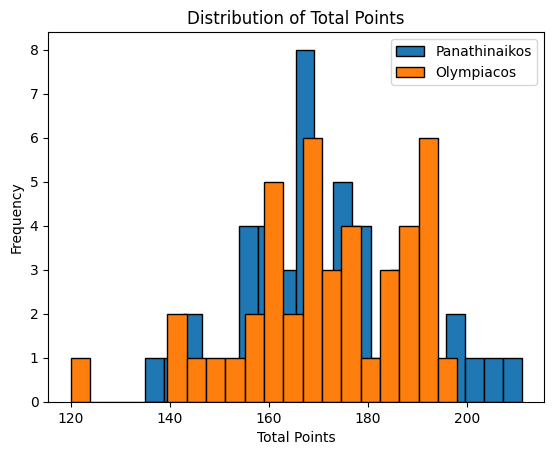

In [37]:
import matplotlib.pyplot as plt
plt.hist(pao_game_points['TotalPoints'], bins=20, edgecolor='black')
plt.hist(oly_game_points['TotalPoints'], bins=20, edgecolor='black')
plt.xlabel('Total Points')
plt.ylabel('Frequency')
plt.title('Distribution of Total Points')
plt.legend(['Panathinaikos', 'Olympiacos'])
plt.show()

In [48]:
import numpy as np
import pandas as pd
import plotly.express as px

bins = [-np.inf, 155, 160, 165, 170, 175, 180, np.inf]
labels = ['<155', '155-160', '160-165', '165-170', '170-175', '175-180', '180+']

# Make sure TotalPoints is numeric
pao_game_points['TotalPoints'] = pd.to_numeric(pao_game_points['TotalPoints'], errors='coerce')

# Create ranges
pao_game_points['PointRange'] = pd.cut(
    pao_game_points['TotalPoints'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Count games in each range
hist = pao_game_points['PointRange'].value_counts().reindex(labels, fill_value=0).reset_index()
hist.columns = ['PointRange', 'Games']

print(hist)

# Plot
fig = px.bar(
    hist,
    x='PointRange',
    y='Games',
    text='Games',
    title='PAO Total Points Distribution'
)
fig.update_traces(textposition='outside')
fig.update_xaxes(title_text='Point range')
fig.update_yaxes(title_text='Games')
fig.show()

  PointRange  Games
0       <155      5
1    155-160      5
2    160-165      5
3    165-170      8
4    170-175      2
5    175-180      7
6       180+     12


Try to compare how many fouls are drawn and committed in the OLY for closed games

In [58]:
boxolyonly=boxscoredata.get_players_boxscore_stats_single_season(season=2025)

Season 2025: 100%|██████████| 402/402 [03:33<00:00,  1.88it/s]


In [62]:
oly_onlyplays = boxolyonly[boxolyonly['Gamecode'].isin(gamecodesoly)].copy()

In [78]:
checkonlyolympiacos=oly_onlyplays[oly_onlyplays['Team'] == 'OLY']
checkoppoly=oly_onlyplays[oly_onlyplays['Team'] != 'OLY']

In [92]:
statsgauros=checkonlyolympiacos[checkonlyolympiacos['Player_ID'].isin(['Total'])]

In [119]:
finalopn=checkoppoly[checkoppoly['Player_ID'].isin(['Total'])]
finalopn.columns

Index(['Season', 'Phase', 'Round', 'Gamecode', 'Home', 'Player_ID',
       'IsStarter', 'IsPlaying', 'Team', 'Dorsal', 'Player', 'Minutes',
       'Points', 'FieldGoalsMade2', 'FieldGoalsAttempted2', 'FieldGoalsMade3',
       'FieldGoalsAttempted3', 'FreeThrowsMade', 'FreeThrowsAttempted',
       'OffensiveRebounds', 'DefensiveRebounds', 'TotalRebounds',
       'Assistances', 'Steals', 'Turnovers', 'BlocksFavour', 'BlocksAgainst',
       'FoulsCommited', 'FoulsReceived', 'Valuation', 'Plusminus'],
      dtype='object')

In [108]:
foulsfromopponents,freethrowat=finalopn['FoulsCommited'],finalopn['FreeThrowsAttempted']
#foulsfromopponents.value_counts()
fta_freqopponents=freethrowat.value_counts().sort_index()

In [106]:
foulsfromoly,freethrowoly=statsgauros['FoulsCommited'],statsgauros['FreeThrowsAttempted']
#foulsfromoly.value_counts()
fta_freq =freethrowoly.value_counts().sort_index()

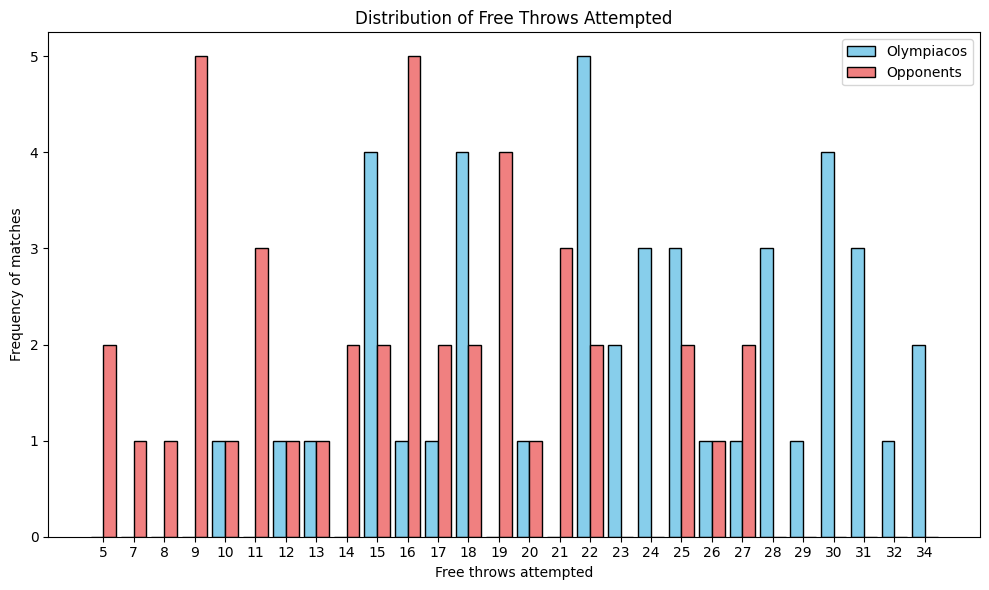

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# unique x values from both teams
all_x = sorted(set(fta_freq.index).union(set(fta_freqopponents.index)))

# counts for each x value
ol_counts = [fta_freq.get(x, 0) for x in all_x]
op_counts = [fta_freqopponents.get(x, 0) for x in all_x]

x = np.arange(len(all_x))
width = 0.42

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ol_counts, width=width, color='skyblue', edgecolor='black', label='Olympiacos')
plt.bar(x + width/2, op_counts, width=width, color='lightcoral', edgecolor='black', label='Opponents')

plt.xticks(x, all_x)
plt.xlabel('Free throws attempted')
plt.ylabel('Frequency of matches')
plt.title('Distribution of Free Throws Attempted')
plt.legend()
plt.tight_layout()
plt.show()

In [149]:
allcodes=[]
for i in range(len(statsgauros[['Points']])):
 diff=float(list(statsgauros['Points'])[i])-  float(list(finalopn['Points'])[i])
 if abs(diff)<10:
    allcodes.append(list(statsgauros['Gamecode'])[i])

In [160]:
fordifference10pointsOLY = statsgauros[statsgauros['Gamecode'].isin(allcodes)].copy()
fordifference10pointsopponnts = finalopn[finalopn['Gamecode'].isin(allcodes)].copy()

In [161]:
fordifference10pointsOLY

,Season,Phase,Round,Gamecode,Home,Player_ID,IsStarter,IsPlaying,Team,Dorsal,...,TotalRebounds,Assistances,Steals,Turnovers,BlocksFavour,BlocksAgainst,FoulsCommited,FoulsReceived,Valuation,Plusminus
55,2025,RS,1,2,0,Total,NaN,NaN,OLY,NaN,...,43,19,10,10,0,3,16,23,127,NaN
934,2025,RS,4,34,1,Total,NaN,NaN,OLY,NaN,...,39,14,6,14,3,4,18,24,90,NaN
1200,2025,RS,5,43,0,Total,NaN,NaN,OLY,NaN,...,33,26,2,16,3,3,21,24,115,NaN
1941,2025,RS,7,70,1,Total,NaN,NaN,OLY,NaN,...,36,16,3,13,2,0,23,26,98,NaN
2191,2025,RS,8,79,1,Total,NaN,NaN,OLY,NaN,...,44,16,4,16,3,2,16,18,71,NaN
2469,2025,RS,9,89,1,Total,NaN,NaN,OLY,NaN,...,40,17,8,18,2,1,14,22,97,NaN
3012,2025,RS,11,108,0,Total,NaN,NaN,OLY,NaN,...,29,20,3,7,2,1,16,18,101,NaN
4306,2025,RS,16,155,1,Total,NaN,NaN,OLY,NaN,...,29,22,6,10,3,1,17,22,109,NaN
5016,2025,RS,18,180,0,Total,NaN,NaN,OLY,NaN,...,40,19,2,18,4,0,24,26,115,NaN
5239,2025,RS,19,188,0,Total,NaN,NaN,OLY,NaN,...,39,21,4,13,4,2,18,24,106,NaN


In [162]:
foulsoly10pointsdif,freeoly10pointsdif=fordifference10pointsOLY['FoulsCommited'],fordifference10pointsOLY['FreeThrowsAttempted']
#foulsfromopponents.value_counts()
fta_freq10pointsdifoly=freeoly10pointsdif.value_counts().sort_index()
fta_freq10pointsdifoly

FreeThrowsAttempted
10    1
13    1
16    1
17    1
18    3
22    2
23    1
24    1
25    2
27    1
28    2
30    2
31    2
32    1
34    1
Name: count, dtype: int64

In [163]:
foulsfromopponents10pointsdif,freethrowat10pointsdif=fordifference10pointsopponnts['FoulsCommited'],fordifference10pointsopponnts['FreeThrowsAttempted']
#foulsfromopponents.value_counts()
fta_freqopponents10pointsdif=freethrowat10pointsdif.value_counts().sort_index()

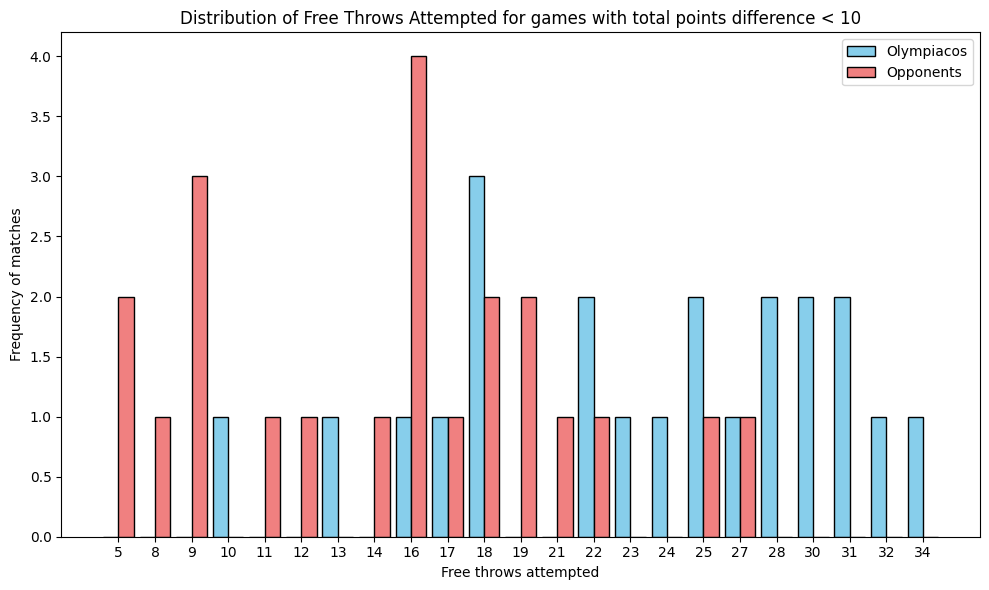

In [164]:
import numpy as np
import matplotlib.pyplot as plt

# unique x values from both teams
all_x = sorted(set(fta_freq10pointsdifoly.index).union(set(fta_freqopponents10pointsdif.index)))

# counts for each x value
ol_counts = [fta_freq10pointsdifoly.get(x, 0) for x in all_x]
op_counts = [fta_freqopponents10pointsdif.get(x, 0) for x in all_x]

x = np.arange(len(all_x))
width = 0.42

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ol_counts, width=width, color='skyblue', edgecolor='black', label='Olympiacos')
plt.bar(x + width/2, op_counts, width=width, color='lightcoral', edgecolor='black', label='Opponents')

plt.xticks(x, all_x)
plt.xlabel('Free throws attempted')
plt.ylabel('Frequency of matches')
plt.title('Distribution of Free Throws Attempted for games with total points difference < 10')
plt.legend()
plt.tight_layout()
plt.show()